<a href="https://colab.research.google.com/github/Chethana-0711/ML-LAB/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.9824561403508771

Confusion Matrix:
 [[46  1]
 [ 1 66]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        47
           1       0.99      0.99      0.99        67

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



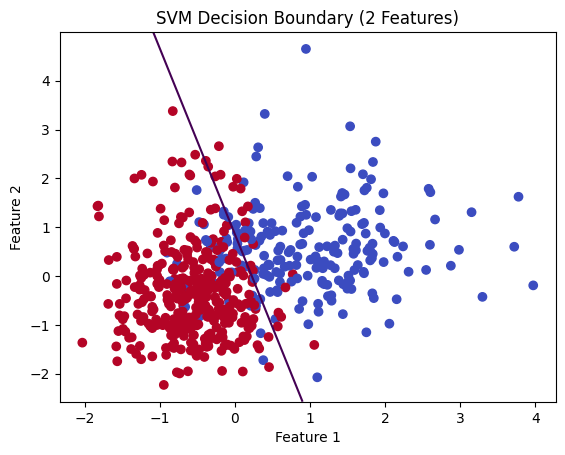

In [1]:


# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Load Dataset (Breast Cancer Dataset)
data = load_breast_cancer()
X = data.data
y = data.target

# 3. Split Data into Train & Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# 4. Standardize the Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Train SVM Model (Linear Kernel)
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# 6. Predictions
y_pred = model.predict(X_test)

# 7. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Visualization (using first 2 features only)
from sklearn.svm import SVC

X_vis = X[:, :2]  # take only first 2 features for plotting

# scale visualization data
scaler_vis = StandardScaler()
X_vis = scaler_vis.fit_transform(X_vis)

# train model on 2 features
model_vis = SVC(kernel='linear')
model_vis.fit(X_vis, y)

# plot decision boundary
plt.figure()

# scatter points
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap='coolwarm')

# create grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model_vis.decision_function(xy).reshape(XX.shape)

# plot decision boundary
ax.contour(XX, YY, Z, levels=[0])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary (2 Features)")
plt.show()